<a href="https://colab.research.google.com/github/zcanozturk/eye-tracking-analysis/blob/main/eye_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Analysis of Eye Movements Across Naturalistic Tasks

## Introduction

Understanding how humans allocate visual attention is a central question in cognitive science and neuroscience. Eye-tracking provides a direct behavioural measure of attention by capturing where and how long individuals look at different regions of a visual scene.

In this notebook, we explore eye-tracking data collected during different desktop activities (e.g., reading, writing, browsing). The goal is to investigate how gaze behaviour changes depending on task demands.

This analysis is exploratory and aims to develop an intuition for how attention operates in naturalistic contexts.

# Exploratory Analysis of Eye Movements

## Project Setup

In this notebook, we will:

1. Connect Google Colab to Kaggle
2. Download the eye-tracking dataset
3. Load and combine the CSV files
4. Inspect the dataset structure
5. Begin exploratory analysis of gaze behaviour across tasks

The aim is to build a small research-style notebook using real eye-tracking data.

In [3]:
# Upload your Kaggle API key file: kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zlfikarztrk","key":"a6bde669d43393750c680c0199f6e84c"}'}

## Kaggle Authentication

Kaggle requires an API key for downloading datasets programmatically.

After uploading `kaggle.json`, we place it in the correct directory and set permissions.

In [4]:
import os

# Create Kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json into the Kaggle config folder
!cp kaggle.json /root/.kaggle/

# Set correct permissions
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


## Download the Dataset

We now download the dataset from Kaggle using the dataset identifier.

In [5]:
!kaggle datasets download -d namratasri01/eye-movement-data-set-for-desktop-activities

Dataset URL: https://www.kaggle.com/datasets/namratasri01/eye-movement-data-set-for-desktop-activities
License(s): copyright-authors
100% 10.4M/10.4M [00:00<00:00, 76.9MB/s]



## Unzip the Downloaded Files

The dataset is downloaded as a ZIP archive, so we extract it before loading the files.

In [6]:
!unzip -o eye-movement-data-set-for-desktop-activities.zip

Archive:  eye-movement-data-set-for-desktop-activities.zip
  inflating: dataset_normalised_5mins/P01_BROWSE.csv  
  inflating: dataset_normalised_5mins/P01_DEBUG.csv  
  inflating: dataset_normalised_5mins/P01_INTERPRET.csv  
  inflating: dataset_normalised_5mins/P01_PLAY.csv  
  inflating: dataset_normalised_5mins/P01_READ.csv  
  inflating: dataset_normalised_5mins/P01_SEARCH.csv  
  inflating: dataset_normalised_5mins/P01_WATCH.csv  
  inflating: dataset_normalised_5mins/P01_WRITE.csv  
  inflating: dataset_normalised_5mins/P02_BROWSE.csv  
  inflating: dataset_normalised_5mins/P02_DEBUG.csv  
  inflating: dataset_normalised_5mins/P02_INTERPRET.csv  
  inflating: dataset_normalised_5mins/P02_PLAY.csv  
  inflating: dataset_normalised_5mins/P02_READ.csv  
  inflating: dataset_normalised_5mins/P02_SEARCH.csv  
  inflating: dataset_normalised_5mins/P02_WATCH.csv  
  inflating: dataset_normalised_5mins/P02_WRITE.csv  
  inflating: dataset_normalised_5mins/P03_BROWSE.csv  
  inflating: d

In [7]:
import os

print(os.listdir())

['.config', 'kaggle.json', 'eye-movement-data-set-for-desktop-activities.zip', 'dataset_normalised_5mins', 'sample_data']


In [8]:
print(os.listdir("dataset_normalised_5mins")[:10])

['P13_WRITE.csv', 'P07_INTERPRET.csv', 'P01_READ.csv', 'P09_DEBUG.csv', 'P05_DEBUG.csv', 'P10_SEARCH.csv', 'P21_BROWSE.csv', 'P24_READ.csv', 'P13_BROWSE.csv', 'P11_READ.csv']


## Load All CSV Files

Each CSV file appears to correspond to a participant-task combination.

We load all CSV files and combine them into one dataframe.

In [9]:
import pandas as pd
import glob

csv_files = glob.glob("dataset_normalised_5mins/*.csv")

print(f"Number of CSV files found: {len(csv_files)}")
print("First few files:", csv_files[:5])

Number of CSV files found: 192
First few files: ['dataset_normalised_5mins/P13_WRITE.csv', 'dataset_normalised_5mins/P07_INTERPRET.csv', 'dataset_normalised_5mins/P01_READ.csv', 'dataset_normalised_5mins/P09_DEBUG.csv', 'dataset_normalised_5mins/P05_DEBUG.csv']


In [10]:
df_list = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    temp_df["source_file"] = file
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Data loaded successfully.")
print("Shape:", df.shape)
df.head()

Data loaded successfully.
Shape: (1505813, 7)


,participant,set,activity,x,y,timestamp,source_file
0,P13,A,WRITE,1060,537,0,dataset_normalised_5mins/P13_WRITE.csv
1,P13,A,WRITE,1060,542,33,dataset_normalised_5mins/P13_WRITE.csv
2,P13,A,WRITE,702,441,66,dataset_normalised_5mins/P13_WRITE.csv
3,P13,A,WRITE,601,428,101,dataset_normalised_5mins/P13_WRITE.csv
4,P13,A,WRITE,615,355,135,dataset_normalised_5mins/P13_WRITE.csv


## Dataset Overview

Each row represents a single gaze sample.

Key variables:
- `participant`: participant ID
- `set`: dataset grouping
- `activity`: task being performed
- `x`, `y`: gaze coordinates
- `timestamp`: time in milliseconds
- `source_file`: original CSV filename

In [11]:
print("Columns:")
print(df.columns)

print("\nUnique activities:")
print(df["activity"].unique())

print("\nNumber of participants:")
print(df["participant"].nunique())

print("\nDataset shape:")
print(df.shape)

Columns:
Index(['participant', 'set', 'activity', 'x', 'y', 'timestamp', 'source_file'], dtype='object')

Unique activities:
['WRITE' 'INTERPRET' 'READ' 'DEBUG' 'SEARCH' 'BROWSE' 'PLAY' 'WATCH']

Number of participants:
24

Dataset shape:
(1505813, 7)


## Data Reduction

The dataset is large, so we take a random sample for initial exploratory analysis.

In [12]:
df_sample = df.sample(100000, random_state=42)
print(df_sample.shape)

(100000, 7)


## Raw Gaze Distribution

We begin by visualising raw gaze points across the sampled data.

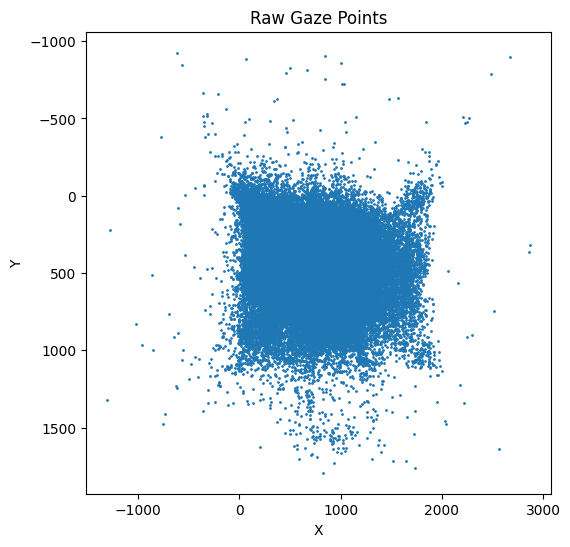

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(df_sample["x"], df_sample["y"], s=1)
plt.gca().invert_yaxis()
plt.title("Raw Gaze Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Gaze Behaviour Across Activities

We now separate gaze points by activity to explore how attention changes with task demands.

In [15]:
activities = df_sample["activity"].unique()
print(activities)

['PLAY' 'BROWSE' 'READ' 'SEARCH' 'DEBUG' 'WATCH' 'INTERPRET' 'WRITE']


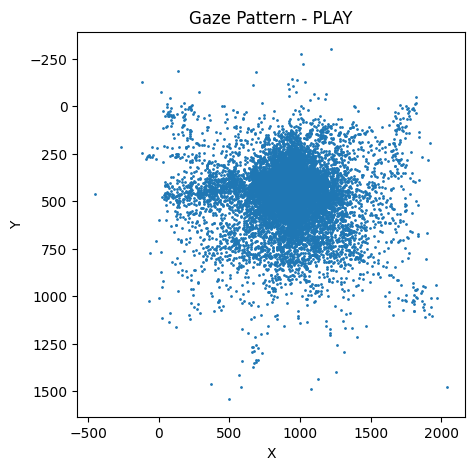

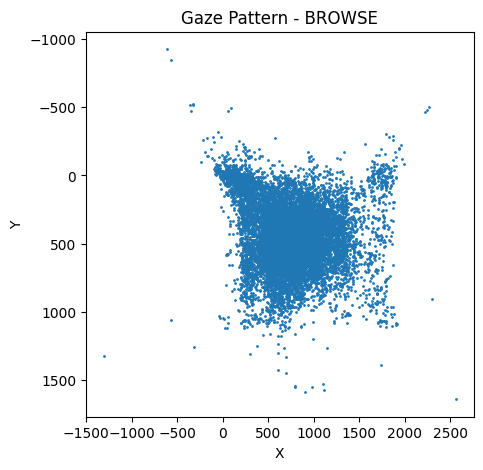

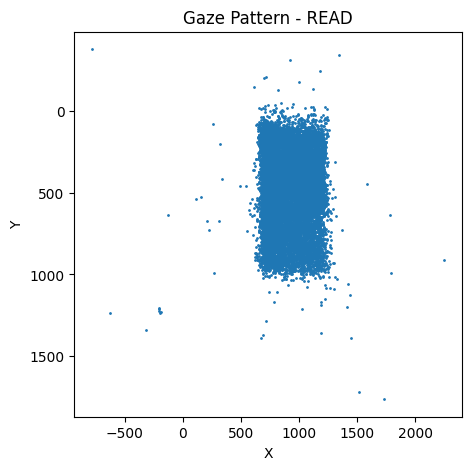

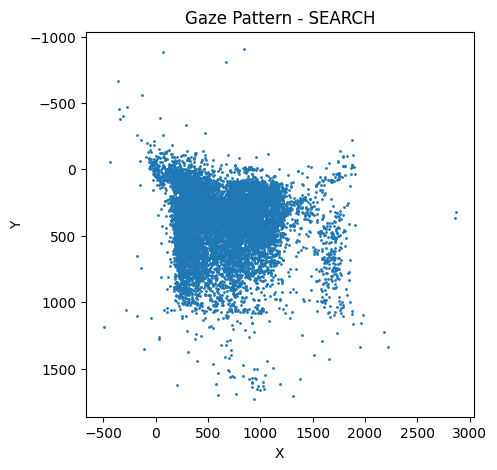

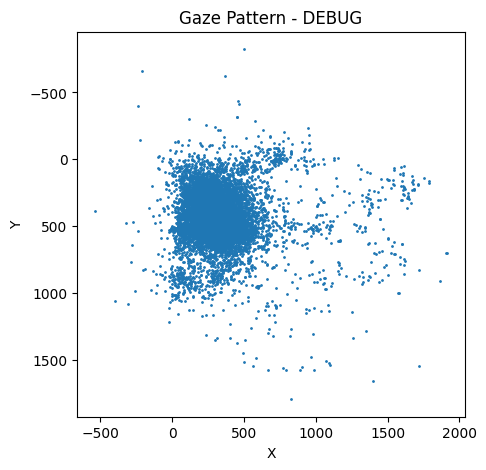

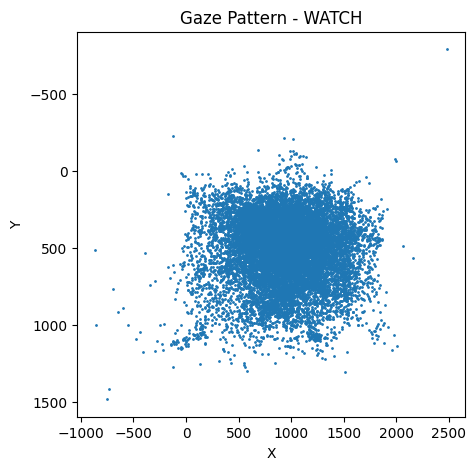

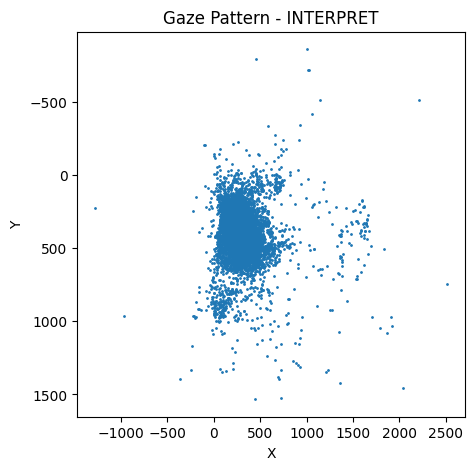

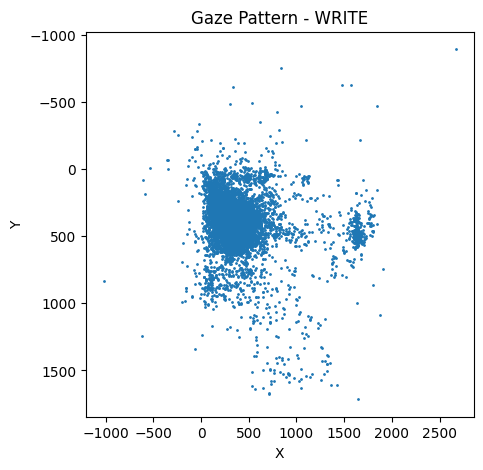

In [16]:
for act in activities:
    subset = df_sample[df_sample["activity"] == act]

    plt.figure(figsize=(5, 5))
    plt.scatter(subset["x"], subset["y"], s=1)
    plt.gca().invert_yaxis()
    plt.title(f"Gaze Pattern - {act}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

## Attention Heatmaps

Density plots help show where gaze is concentrated for each activity.

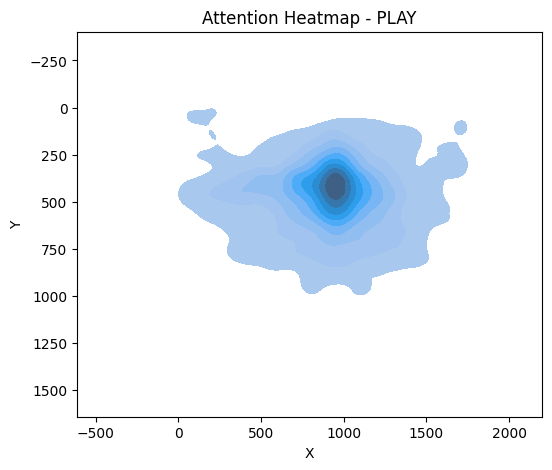

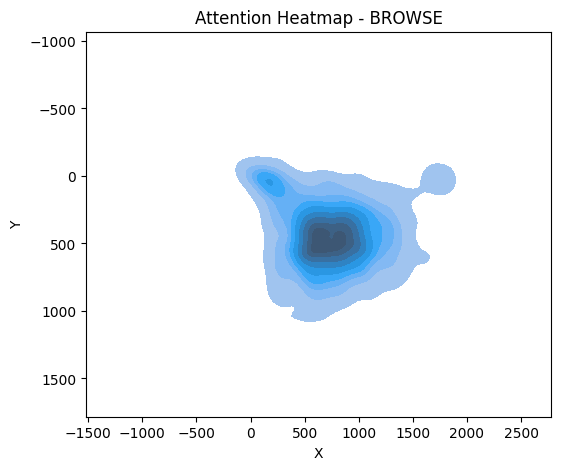

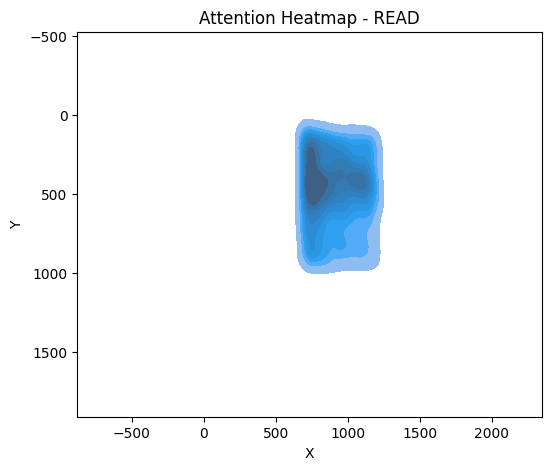

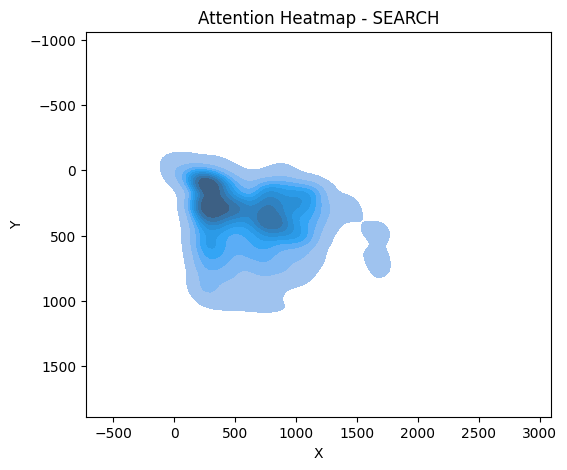

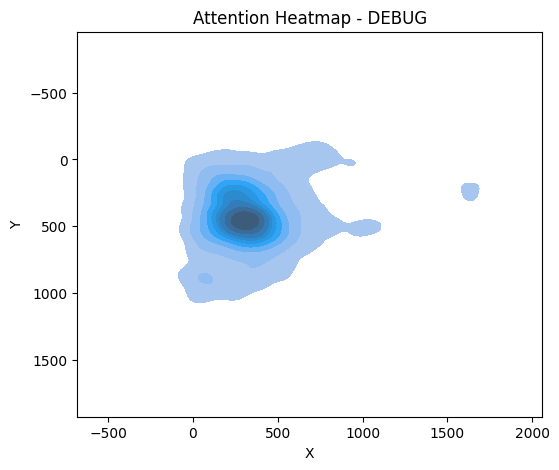

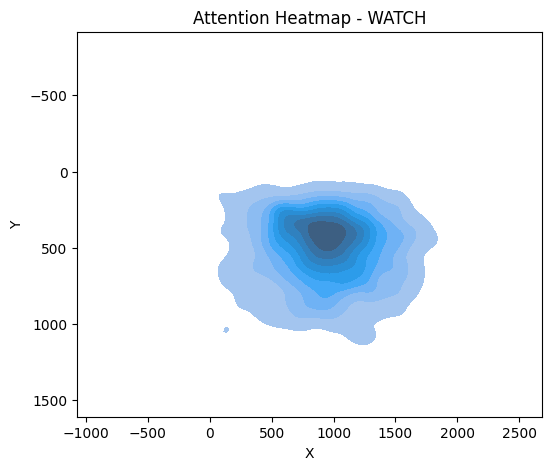

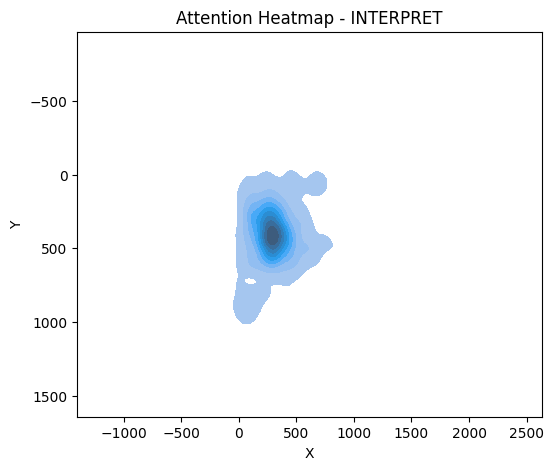

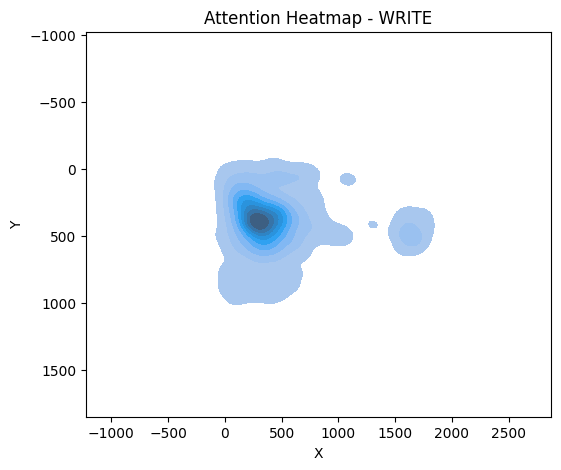

In [17]:
import seaborn as sns

for act in activities:
    subset = df_sample[df_sample["activity"] == act]

    plt.figure(figsize=(6, 5))
    sns.kdeplot(
        x=subset["x"],
        y=subset["y"],
        fill=True
    )
    plt.gca().invert_yaxis()
    plt.title(f"Attention Heatmap - {act}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

## Attention Heatmaps

Density plots help show where gaze is concentrated for each activity.

## Temporal Dynamics

We inspect how gaze coordinates change over time for one example activity.

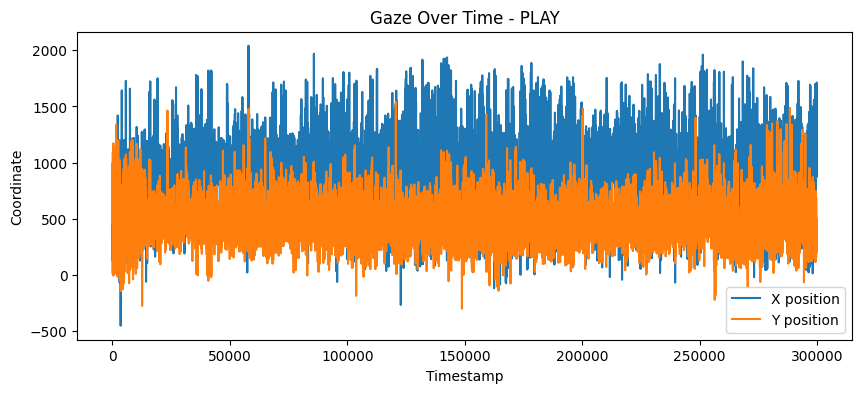

In [19]:
example_activity = activities[0]
subset = df_sample[df_sample["activity"] == example_activity].sort_values("timestamp")

plt.figure(figsize=(10, 4))
plt.plot(subset["timestamp"], subset["x"], label="X position")
plt.plot(subset["timestamp"], subset["y"], label="Y position")
plt.legend()
plt.title(f"Gaze Over Time - {example_activity}")
plt.xlabel("Timestamp")
plt.ylabel("Coordinate")
plt.show()

## Summary Statistics

We compute simple descriptive statistics for each activity.

In [20]:
summary = df_sample.groupby("activity").agg({
    "x": ["mean", "std"],
    "y": ["mean", "std"],
    "timestamp": "count"
})

summary

x                       y             timestamp
                 mean         std        mean         std     count
activity                                                           
BROWSE     751.818852  349.508869  442.645290  235.136973     14237
DEBUG      331.521331  222.262018  433.395944  205.444758     10009
INTERPRET  309.996104  186.228319  408.157684  168.944884      9240
PLAY       924.044396  260.967820  463.918099  167.014443     14078
READ       915.547686  163.435199  490.488883  240.143246     14302
SEARCH     630.670406  360.993290  382.630497  250.350805     12303
WATCH      939.613498  342.581777  502.276594  215.476257     16714
WRITE      395.136668  308.060226  396.858506  199.585617      9117

## Conclusion

This notebook demonstrates a complete workflow from Kaggle download to exploratory analysis of eye-tracking data in Google Colab.

It provides a simple starting point for studying attention in naturalistic tasks and could be extended with:
- fixation detection
- participant-level comparisons
- task-specific modelling
- links to cognitive or neural theories of attention